<h1 style="text-align:center; color:green; font-size:48px;">
DHNx PROJECT - STEP 1
</h1>

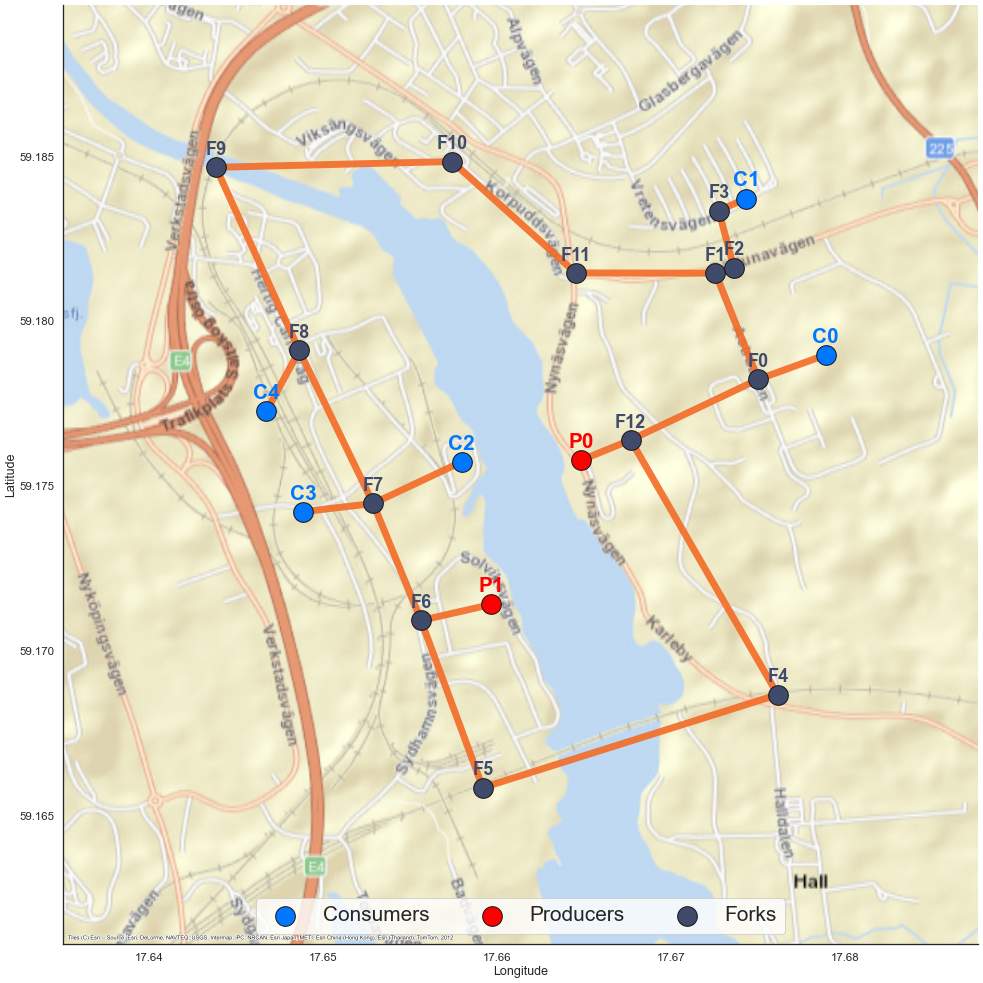

In [29]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import contextily as ctx
from DHNx_gen_map import plot_dhn_map

network = dhnx.network.ThermalNetwork()
network = network.from_csv_folder(r"../2_inputs/1_step_twn_data")
invest_opt = dhnx.input_output.load_invest_options(r"../2_inputs/1_step_invest_data")

fig, ax = plot_dhn_map(network)
plt.show()




<h1 style="text-align:center; color:green; font-size:48px;">
OPTIMIZE THE NETWORK
</h1>

In [30]:
network.optimize_investment(invest_options=invest_opt,  solver='gurobi')

INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\network\nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.
INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires 2026-10-30
Read LP format model from file C:\Users\ardia\AppData\Local\Temp\tmp1kfrqijx.pyomo.lp
Reading time = 0.04 seconds
x1: 614 rows, 530 columns, 1388 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 614 rows, 530 columns and 1388 nonzeros
Model fingerprint: 0xad813544
Variable types: 464 continuous, 66 integer (66 binary)
Coefficient statistics:
  Matrix range     [7e-04, 3e+03]
  Objective range  [4e+00, 1e+06]
  Bounds range     [1e+00, 3e+03]
  RHS range        [7e+01, 3e+03]
Presolve removed 476 rows and 344 columns
Presolve time: 0.00s
Presolved: 138 rows, 186 columns, 538 nonzeros
Variable types: 123 continuous, 63 integer (63 binary)
Fou

INFO:root:Optimization successful...


   from_node      to_node hp_type     capacity  direction          costs  \
id                                                                         
0   forks-12      forks-0  DN-150  2728.789249          1  689812.478537   
1    forks-0  consumers-0  DN-150  2597.930231          1  350084.553909   
2    forks-0      forks-1   DN-32    96.973811          1  304844.921904   
3    forks-1      forks-2   DN-32    84.703806          1   46582.994959   
4    forks-2      forks-3   DN-32    82.898571          1  155121.567539   
5    forks-3  consumers-1   DN-32    76.921560          1   77304.050227   
6    forks-1     forks-11    None     0.000000          0       0.000000   
7   forks-11     forks-10    None     0.000000          0       0.000000   
8   forks-10      forks-9    None     0.000000          0       0.000000   
9    forks-9      forks-8    None     0.000000          0       0.000000   
10   forks-8  consumers-4   DN-32   117.091562          1  189670.781780   
11   forks-8

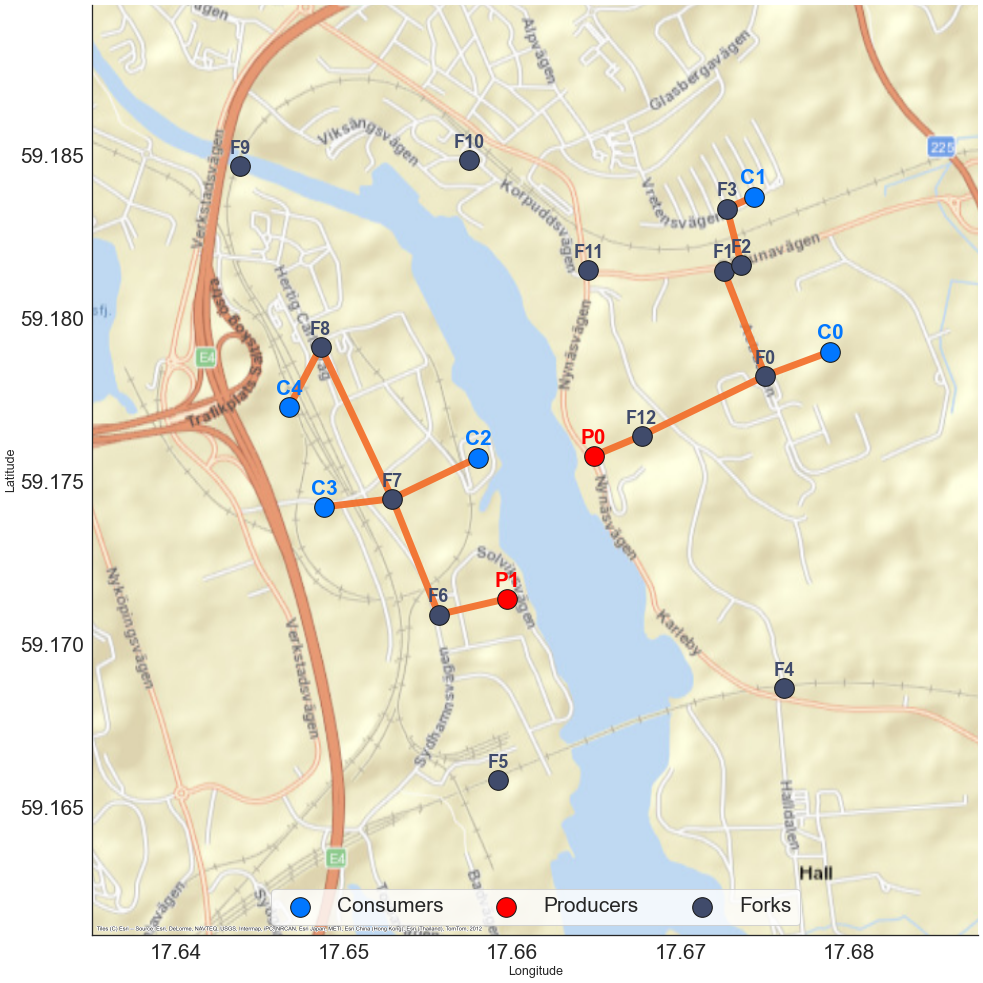

In [26]:
# ####### Postprocessing and Plotting ###########
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])
results_edges.to_csv("../3_outputs/DHNx_step1_result.csv", index=True)

print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]

static_map = dhnx.plotting.StaticMap(twn_results)
fig, ax = static_map.draw(background_map=False)

# Networks pipes
for coll in ax.collections:
    try:
        coll.set_linewidth(10)                    # thicker pipes
        coll.set_color("#F36B26")              # or e.g. "steelblue", "#2E86C1"
        coll.set_alpha(0.9)                      # optional transparency
    except Exception:
        pass  # skip non-line collections
offset = 0.00025   
# Consumers → C
for idx, row in network.components.consumers.iterrows():
    label = "C" + str(row.get("name", idx))
    ax.text(row['lon'], row['lat'] + offset, label,
            fontsize=30, fontweight='bold',
            ha='center', va='bottom', color="#0177FF")

# Producers → P
for idx, row in network.components.producers.iterrows():
    label = "P" + str(row.get("name", idx))
    ax.text(row['lon'], row['lat'] + offset, label,
            fontsize=30, fontweight='bold',
            ha='center', va='bottom', color="#FF0000")

# Forks → F
for idx, row in network.components.forks.iterrows():
    label = "F" + str(row.get("name", idx))
    ax.text(row['lon'], row['lat'] + offset, label,
            fontsize=26, fontweight='bold',
            ha='center', va='bottom', color="#404B6B")

# --- High resolution and figure size
fig.set_size_inches(20,20)
fig.set_dpi(50)

# --- Bounds with margin
lon = pd.concat([
    network.components.consumers['lon'],
    network.components.producers['lon'],
    network.components.forks['lon'],
])
lat = pd.concat([
    network.components.consumers['lat'],
    network.components.producers['lat'],
    network.components.forks['lat'],
])
expand = 0.25
ax.set_xlim(lon.min() - expand*(lon.max()-lon.min()), lon.max() + expand*(lon.max()-lon.min()))
ax.set_ylim(lat.min() - expand*(lat.max()-lat.min()), lat.max() + expand*(lat.max()-lat.min()))

# --- FREE basemap (no API key)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldStreetMap)

# --- Overlays (nodes)
palette = sns.color_palette("Set2", 3)
ax.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
           color="#0177FF", label='Consumers', zorder=6, s=800, edgecolor='k')
ax.scatter(network.components.producers['lon'], network.components.producers['lat'],
           color="#FF0000", label='Producers', zorder=6, s=800, edgecolor='k')
ax.scatter(network.components.forks['lon'], network.components.forks['lat'],
           color="#404B6B", label='Forks', zorder=6, s=800, edgecolor='k')

# --- Cosmetics
# ax.set_title('DH Network', fontsize=28, fontweight='bold')
ax.grid(False)
ax.tick_params(axis='both', labelsize=30)
ax.set_xlabel("Longitude", fontsize=18)
ax.set_ylabel("Latitude", fontsize=18)
ax.legend(loc='lower center', ncol=3, frameon=True, fontsize=30)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

# --- Optional: save high-resolution image
# fig.savefig("DH_network_highres.png", dpi=600, bbox_inches='tight')
